# Precision at fixed candidate budgets, ranked by chromatin density — half-pixel template-centre fix (K = 10, 20, 30, 50)

> **This is the corrected re-run of `production_seed_precision_at_k_chromatin.ipynb`.** That
> notebook's own committed outputs (`results/precision_at_k_14roi_prodseed_chromatin_*.csv`,
> 2026-09-09) were generated by `seed_selection.tightened_template_box` **as it stood that
> day**, which computed the accepted component's bbox centre as `(x0 + x1) / 2`. That formula
> was corrected in place on 2026-09-10 (`D8_TEMPLATE_ANCHOR.md`, commit `ddaf049`): the centre
> is now `(x0 + x1 - 1) / 2`, because the half-open `regionprops` bbox covers pixels
> `x0 .. x1 - 1`, not the seam at `x1`. `tightened_template_box` is the same function, same call
> signature -- nothing in the pipeline below needs to change to pick up the fix; simply
> re-running it does. `D8_TEMPLATE_ANCHOR.md` measured that re-drawing these 14 seeds under the
> corrected formula moves the template centre on 12-13 of them (median 3.10 px), but deliberately
> stopped at "mechanism, not outcome" -- it does not say whether precision@K or the
> best-ranking-arm verdict actually move. That is what this notebook adds, on top of an
> otherwise byte-identical copy:
>
> 1. The pipeline below -- config, `SELF_HIT_RADIUS = 5.0`, the six arms, the budgets -- is
>    unchanged from the original notebook. It differs only in which `tightened_template_box`
>    it links against, which from the caller's point of view is no difference at all.
> 2. A new check verifies `seed_selection.build_seed` -- the new entry point that wraps the
>    inline agreement/border/gate/draw/retry block below -- reproduces this notebook's own
>    inline seed draw exactly, seed by seed, rather than just asserting it by name.
> 3. After the tables, this notebook compares its own (post-fix) `precision_at_K` and
>    `precision_pooled` against the pre-fix committed baseline and reports which ROIs, domains
>    and arms moved, and by how much.
> 4. It closes by naming the best-ranking arm under the corrected seed, so a reader can see
>    directly whether the fix changes *which axis wins*, not just the numbers underneath it.

**Question.** Replicates `precision_at_k_budgets_14roi.ipynb` exactly through NMS -- same 14
ROIs, same one click per ROI, same search, same deep-floor extraction, same NMS -- and changes
only the ranking step. Instead of the single `tm_score` (`TM_CCOEFF`) arm, six arms rank the
same post-NMS candidate pool: `tm_score` (D5's production ranker, included as the baseline) and
five chromatin-density axes named in `DECISIONS.md` D5's "what would change my mind" clause --
`chromatin_od` (`od51`), `od31`, `od_falloff`, `mask_od_mean`, `od_contrast`.

**Scope, fixed for this run:**
- 14 ROIs, `images/extra_valid` (2 per tumour domain x 7 domains).
- 1 seed per ROI, `seed_index = 0` -- drawn via the exact same RNG stream as the notebook this
  copies (checked below, both against the inline draw and against `build_seed`). Because
  `tightened_template_box` now returns a different centre for most of these seeds, the
  resulting template and candidate pool are **not** expected to reproduce the pre-fix reference
  run byte-for-byte -- see the comparison section for that question; Gate 0 below reports the
  divergence rather than asserting it away.
- Today's decided defaults (`DECISIONS.md`): `TM_CCOEFF` (D1), no `tissue_mask` (D2),
  `hematoxylin_od` unclipped (D3), NMS radius = match radius = 7.5 um (D7, enforced via
  `invariants.check_nms_radius`).
- No z-threshold sweep, no seed sweep. Candidates are extracted once per ROI at the permissive
  deep floor (`z = -1.5`), NMS'd at 7.5 um -- exactly as in the reference notebook -- and then
  `compare.evaluate_arms` ranks and re-matches that one pool independently for each of the six
  arms, truncating to K = 10/20/30/50 per arm.
- This is **not** a seed sweep and does not settle D5 (which requires 5 seeds, paired delta
  clustered at the ROI). It reports single-seed precision@K per arm, which is what this
  notebook's own metric can say.

In [1]:
import gc
import time
import sys

import cv2
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import compare as cp
from midog_utils import invariants as inv
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

# ---------------------------------------------------------------------------------------
# Configuration. Identical to `production_seed_precision_at_k_chromatin.ipynb` -- D1/D2/D3/D7
# per DECISIONS.md, SELF_HIT_RADIUS = 5.0, the same six arms, the same budgets. The only
# difference from that notebook is which `tightened_template_box` this process links against
# (corrected in place, 2026-09-10, D8_TEMPLATE_ANCHOR.md) -- no config value here changes.
# ---------------------------------------------------------------------------------------
IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0                       # one seed per ROI

CHANNEL = 'hematoxylin_od'           # D3 -- unclipped optical density
METHOD = cv2.TM_CCOEFF               # D1 -- unnormalized, contrast-sensitive
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5                  # near-unfiltered extraction floor (repo convention)
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM   # 7.5 um -- D7: NMS radius == match radius
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2         # 36
OTSU_WINDOW = tm.BASE_SIZE           # 51

# Chromatin-axis windows (midog_utils.chromatin.chromatin_density, tp_fp_feature_extract's
# shape_features). od31/od51/od81 share `frac=0.10` (chromatin_density's default: mean of the
# darkest 10% of the window); od_ctx uses the darkest half of a wider neighbourhood. One pad
# covers every window used below: 60 px is exactly `read_padded_patch`'s requirement for the
# 121 px od_ctx window (half = window // 2) and more than enough for every smaller one.
OD_WINDOWS = (31, 51, 81)
CTX_WINDOW, CTX_FRAC = 121, 0.50
SHAPE_WINDOW = tm.BASE_SIZE          # 51 -- tp_fp_feature_extract.SHAPE_WINDOW
OD_PAD = CTX_WINDOW // 2             # 60 -- exactly covers od_ctx (121px), the largest window

# rank_key -> the pool column each arm sorts on, descending, NaN last (compare._rank).
# 'tm_score' is the D5 production ranker, included as the baseline every chromatin axis is
# measured against, per D5's own rule that no axis may be judged without that comparison.
AXES = {
    'tm_score':     'score',
    'chromatin_od': 'od51',
    'od31':         'od31',
    'od_falloff':   'od_falloff',
    'mask_od_mean': 'mask_od_mean',
    'od_contrast':  'od_contrast',
}

BUDGETS = (10, 20, 30, 50)           # the fixed candidate-list lengths under test

OUT_PER_ROI = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_per_roi.csv'
OUT_BY_DOMAIN = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_by_domain.csv'
OUT_RAW = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_raw.csv'
OUT_VERIF = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_verification.csv'

# The pre-fix (2026-09-09) tm_score-only reference run, used only for Gate 0's divergence
# report below -- never re-read after that.
REFERENCE_PER_ROI = '../results/precision_at_k_14roi_prodseed_per_roi.csv'

# The pre-fix (2026-09-09) committed baseline for *this* notebook -- what the comparison
# section near the end measures this run's precision@K and precision_pooled against.
OLD_CHROMATIN_PER_ROI = '../results/precision_at_k_14roi_prodseed_chromatin_per_roi.csv'
OLD_CHROMATIN_BY_DOMAIN = '../results/precision_at_k_14roi_prodseed_chromatin_by_domain.csv'

print(f'budgets {BUDGETS} x 14 ROIs x 1 click (seed_index={SEED_INDEX}) x {len(AXES)} arms')
print(f'arms: {list(AXES)}')
print(f'NMS radius = match radius = {NMS_RADIUS_UM} um (D7)')

budgets (10, 20, 30, 50) x 14 ROIs x 1 click (seed_index=0) x 6 arms
arms: ['tm_score', 'chromatin_od', 'od31', 'od_falloff', 'mask_od_mean', 'od_contrast']
NMS radius = match radius = 7.5 um (D7)


## The pipeline

Identical to the notebook this copies, with **one change: how the seed is refined**.

The ancestors of this notebook (`recall_workload_ledger.py` -> `find_and_suppress_high_threshold_precision.ipynb`
-> `precision_at_k_budgets_14roi.ipynb`) carried an inline `largest_cc_box`, which takes the
largest Otsu component in the click's 51 px crop **whether or not the click lands inside it** --
the largest-connected-component fallback `seed_selection.tighten_box_otsu` refuses by design
(`BBOX_TUNING.md` calls it *"a weak heuristic ... in a crowded crop it can grab an unrelated,
larger structure"*). It also kept the template centred on the raw click, correcting only the
size.

This notebook uses `seed_selection.tightened_template_box` (`DECISIONS.md` **D8**, 2026-09-09)
instead, which changes two things at once:

1. **The containment gate is enforced.** `center_tolerance=0`: the click's own pixel must be
   foreground of the accepted component, or the seed is refused (`None`) and
   `draw_seed_with_retry` redraws on the same RNG stream. The sanity gates behind it
   (`min_area=50`, `max_area_frac=0.85`, `min_solidity=0.5`) are unchanged -- they are
   `tighten_box_otsu`'s own defaults and the same values the inline helper passed.
2. **The template is recentred on the accepted component's own bbox centre**, not the click.
   D8's measurement on these 14 ROIs: `tighten_box_otsu` accepts 896/993 (90.2%) of unanimous
   border-filtered mitotic annotations, and among those the click-to-centre offset runs a
   median 3.10 px, 95th percentile 8.14 px, max 13.87 px -- against templates of roughly
   19-51 px, so not a small correction.

**The three consequences D8 says the caller owns, and how they are handled here:**

* **Self-hit removal moves with the centre** (D8 item 1). `suppress()` and the seed-annulus
  diagnostic are both referenced to `tpl_xy`, the recentred point, not to the click.
* **Border safety moves with the centre** (D8 item 2). `border_filter` runs on the click as
  before, then `_check` additionally verifies the full rotation-safe patch is readable at the
  recentred point, refusing the seed if not.
* **Ground truth does not move** (D8 item 3). `(cx, cy)` stays the click for `gt_eval`
  exclusion and for every MIDOG match-radius computation. Only where the template is built
  from changes; what counts as finding a mitotic figure does not.

Everything downstream of the seed -- channel, method, augmentation, deep floor, NMS radius,
ranking, budgets, tables -- is byte-identical to the notebook this copies.

In [2]:
# D8 (`DECISIONS.md`, 2026-09-09): seed sizing AND centring come from
# `seed_selection.tightened_template_box`, so the inline `_odd_local` / `largest_cc_box`
# pair this notebook's ancestors carried is gone. The two rules are not equivalent:
# `largest_cc_box` took the largest Otsu component in the click's crop whether or not the
# click landed in it -- the largest-connected-component fallback `tighten_box_otsu`
# refuses by design. `tightened_template_box` keeps that containment gate exactly as it
# stands (center_tolerance=0: the click's own pixel must be foreground of the accepted
# component, else the seed is refused and redrawn) and adds the component's own bbox
# centre. Its sanity gates are `tighten_box_otsu`'s defaults -- min_area=50,
# max_area_frac=0.85, min_solidity=0.5 -- the same values the inline helper used.


def draw_seed_with_retry(pool, rng, check_fn):
    '''Draw a row via `rng.integers`; on failure drop it and redraw on the same stream.'''
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, ref_xy):
    '''NMS at `radius`, then drop the template's own self-correlation. Returns (centers, scores).

    `ref_xy` is the point the template was built from -- under D8 the accepted Otsu
    component's own bbox centre, not the raw click. The self-correlation peak lands where the
    template is centred, so self-hit removal (and the seed-annulus diagnostic below) must both
    be referenced there: D8, "what it costs", item 1.

    SELF_HIT_RADIUS is the repo default 5.0 px (`FSConfig.self_hit_radius`).
    `find_and_suppress.py` keeps this filter deliberately tight rather than using the match
    radius: the minimum spacing between two real MIDOG++ annotations anywhere in the dataset
    is 26.2 px, below the ~30 px match radius, so a match-radius filter could delete a
    legitimate detection of a neighbouring ground-truth object.
    '''
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - ref_xy[0], c[:, 1] - ref_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def shape_features(chan, cx, cy, window=SHAPE_WINDOW):
    '''Largest Otsu component under a point, measured with no accept/reject gate.

    Copied from `tp_fp_feature_extract.py` -- same thresholding as `largest_cc_box` (per-patch
    min-max to uint8, then binary Otsu, then the largest connectivity-2 component) with every
    gate removed, so `mask_od_mean` is defined for every candidate Otsu finds any foreground in
    (D6: gate-free beats the gated version on AUC, look-alike contrast and read_95). Returns
    None only when the window is unreadable or Otsu finds no foreground at all -- the caller
    ranks that `nan`, last, rather than dropping the candidate.
    '''
    patch = tm.read_padded_patch(chan, cx, cy, window)
    if patch is None:
        return None
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    regions = regionprops(label(binary, connectivity=2), intensity_image=patch)
    if not regions:
        return None
    r = max(regions, key=lambda x: x.area)
    return {'mask_od_mean': float(r.intensity_mean)}


def roi_files(images_dir=IMAGES_DIR):
    import os
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


print(f'{len(roi_files())} ROIs on disk in {IMAGES_DIR}/')

14 ROIs on disk in ../images/extra_valid/


## The run

Per ROI: one `matchTemplate` pass (the expensive step, ~15 s), one extraction at the deep
floor, one NMS at 7.5 um -- identical to the reference notebook. Then, on the surviving pool:
one border-replicate pad at 60 px, four `chromatin_density` windows (31/51/81 px darkest-10%,
121 px darkest-50%) and one gate-free Otsu pass per candidate (`shape_features`), from which
`od_contrast = od51 - od_ctx` and `od_falloff = od31 - od81` are derived. Six `compare.Arm`s --
`tm_score` plus five chromatin axes -- then rank and re-match this one pool independently
(`compare.evaluate_arms`, `midog_utils/compare.py`), so precision@K for every axis comes from
the *same* candidates, differing only in sort order.

In [3]:
def run_roi(fn, image_id, domain, anns):
    t0 = time.time()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    del rgb
    gc.collect()

    # --- the click -------------------------------------------------------------------
    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        # D8: `tightened_template_box` applies `tighten_box_otsu`'s containment gate --
        # the click's own pixel (center_tolerance=0) must land inside the accepted
        # component, or the seed is refused (None) and `draw_seed_with_retry` redraws on
        # the same RNG stream. It returns (base_size, center_x, center_y), the centre in
        # full-image coordinates.
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        # D8 "what it costs", item 2: border safety moves with the centre. `border_filter`'s
        # margin (BORDER) was sized for a click-centred read, and the recentred point can sit
        # further toward the ROI edge, so re-check that the full rotation-safe patch is
        # actually readable there instead of assuming the click's own check still covers it.
        if tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed, seed_tpl, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    base_size, tpl_cx, tpl_cy = seed_tpl
    tpl_xy = (float(tpl_cx), float(tpl_cy))           # D8: where the template is built from
    seed_xy = (float(seed['cx']), float(seed['cy']))  # D8 item 3: ground truth stays the click
    tpl_offset = float(np.hypot(tpl_xy[0] - seed_xy[0], tpl_xy[1] - seed_xy[1]))
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    del gray_inv
    gc.collect()

    # --- one match, one deep-floor extraction, one NMS -- no z-sweep --------------------
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding left part of the ROI unreachable (PAD={PAD})'
    del hem_p, fused_p, valid_p
    gc.collect()

    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    n_peaks = len(centers)
    assert n_peaks < MAX_PEAKS, f'{fn}: MAX_PEAKS is binding, raise it'
    c, s = suppress(centers, scores, nms_radius, tpl_xy)
    assert bool(np.all(np.diff(s) <= 0)), f'{fn}: post-NMS pool is not score-descending'
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})

    # Seed annulus: at NMS radius == match radius, NMS itself empties this before self-hit
    # removal ever runs (the self-correlation is the map's global maximum, kept first, and
    # suppresses everything within one NMS radius) -- so this must count zero here.
    d_seed = np.hypot(pool['cx'] - tpl_xy[0], pool['cy'] - tpl_xy[1])
    n_near_seed = int((d_seed <= match_radius).sum())

    del fused, valid, templates, patch, centers, scores, c, s
    gc.collect()

    # --- chromatin axes on the NMS survivors -- one pad covers every window used below ---
    hem_pad = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, cv2.BORDER_REPLICATE)
    px = pool['cx'].to_numpy() + OD_PAD
    py = pool['cy'].to_numpy() + OD_PAD
    for w in OD_WINDOWS:
        pool[f'od{w}'] = [cm.chromatin_density(hem_pad, x, y, window=w) for x, y in zip(px, py)]
    pool['od_ctx'] = [cm.chromatin_density(hem_pad, x, y, window=CTX_WINDOW, frac=CTX_FRAC)
                      for x, y in zip(px, py)]
    pool['od_contrast'] = pool['od51'] - pool['od_ctx']
    pool['od_falloff'] = pool['od31'] - pool['od81']
    n_od_nan = int(pool[[f'od{w}' for w in OD_WINDOWS] + ['od_ctx']].isna().sum().sum())
    assert n_od_nan == 0, f'{fn}: {n_od_nan} NaN od survived the {OD_PAD} px pad'

    shape_rows = [shape_features(hem_pad, x, y, window=SHAPE_WINDOW) for x, y in zip(px, py)]
    shape_ok = np.array([r is not None for r in shape_rows])
    pool['mask_od_mean'] = [r['mask_od_mean'] if r is not None else np.nan for r in shape_rows]
    shape_fail_rate = float(1 - shape_ok.mean()) if len(shape_ok) else float('nan')

    del hem, hem_pad
    gc.collect()

    # --- six arms, one pool, independent rank + re-match per arm -------------------------
    # coverage_key=fn: all six arms share the same candidate positions (same `pool`, just
    # resorted), and coverage_fraction depends only on those positions, not rank order or
    # rank_key (evaluate.coverage_fraction takes only cx, cy) -- so evaluate_arms's own
    # coverage_cache computes it once per ROI on the first arm and reuses it for the rest.
    arms = [
        cp.Arm(name, (lambda d=pool: d), rank_key=key, seeded=True, z=DEEP_FLOOR_Z,
               z_dependent=True, nms_radius=nms_radius, caps=(MAX_PEAKS,), coverage_key=fn)
        for name, key in AXES.items()
    ]
    ctx = dict(file_name=fn, tumor_type=domain, image_id=image_id,
               seed_ann_id=seed_ann_id, base_size=base_size,
               map_median=round(float(med), 5), mad_scale=round(float(mad), 5), mpp=mpp)
    checks = []
    out = cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=(H, W), mpp=mpp,
                            budgets=BUDGETS, context=ctx, checks=checks)

    checks.append(dict(check='seed_annulus_empty', label=fn, n_near_seed=n_near_seed,
                       match_radius_px=round(match_radius, 3), passed=bool(n_near_seed == 0)))

    meta = dict(file_name=fn, tumor_type=domain, image_id=image_id, seed_ann_id=seed_ann_id,
                n_retries=n_retries, contested_seed_tier=bool(flagged), base_size=base_size,
                tpl_cx=tpl_xy[0], tpl_cy=tpl_xy[1], tpl_offset_px=round(tpl_offset, 3),
                mpp=mpp, roi_h=int(H), roi_w=int(W), pad_px=PAD,
                match_radius_px=match_radius, nms_radius_px=nms_radius,
                map_median=float(med), mad_scale=float(mad), n_gt_mitotic=n_gt,
                n_detections=len(pool), n_near_seed_annulus=n_near_seed,
                shape_fail_rate=round(shape_fail_rate, 5),
                t_total_s=round(time.time() - t0, 1))
    print(f"[{fn}] {domain:32s} base={base_size:2d} n_detections={len(pool):6d} "
          f"n_gt={n_gt:3d} shape_fail={shape_fail_rate:.3%} [{meta['t_total_s']:.0f}s]", flush=True)
    return out, pd.DataFrame(checks), meta

In [4]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
missing = sorted(set(files) - set(meta_ix.index))
assert not missing, f'.tiff on disk absent from the annotation DB: {missing}'
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

t_run = time.time()
out_frames, check_frames, roi_meta = [], [], []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    out, checks, m = run_roi(fn, image_id, domain, annotations)
    out_frames.append(out)
    check_frames.append(checks)
    roi_meta.append(m)
    gc.collect()

RAW = pd.concat(out_frames, ignore_index=True)
VERIF = pd.concat(check_frames, ignore_index=True)
ROI = pd.DataFrame(roi_meta).set_index('file_name')

print(f'\n{len(files)} ROIs x {len(BUDGETS)} budgets x {len(AXES)} arms = {len(RAW)} rows in {time.time() - t_run:.0f}s')
ROI[['tumor_type', 'seed_ann_id', 'base_size', 'tpl_offset_px', 'n_gt_mitotic', 'n_detections',
     'match_radius_px', 'nms_radius_px', 'map_median', 'mad_scale', 'shape_fail_rate',
     't_total_s']].round(3)

[013.tiff] human breast cancer              base=31 n_detections= 17724 n_gt= 17 shape_fail=0.000% [73s]


[094.tiff] human breast cancer              base=25 n_detections= 18628 n_gt= 81 shape_fail=0.000% [71s]


[201.tiff] canine lung cancer               base=51 n_detections= 15848 n_gt= 17 shape_fail=0.000% [29s]


[233.tiff] canine lung cancer               base=25 n_detections= 17449 n_gt= 17 shape_fail=0.000% [24s]


[245.tiff] canine lymphosarcoma             base=47 n_detections= 17678 n_gt= 89 shape_fail=0.000% [29s]


...

[460.tiff] canine soft tissue sarcoma       base=47 n_detections= 15698 n_gt= 35 shape_fail=0.000% [20s]


[529.tiff] human melanoma                   base=37 n_detections= 16620 n_gt= 19 shape_fail=0.000% [28s]


[548.tiff] human melanoma                   base=29 n_detections= 17839 n_gt=238 shape_fail=0.000% [21s]



14 ROIs x 4 budgets x 6 arms = 336 rows in 447s


,tumor_type,seed_ann_id,base_size,tpl_offset_px,n_gt_mitotic,n_detections,match_radius_px,nms_radius_px,map_median,mad_scale,shape_fail_rate,t_total_s
file_name,,,,,,,,,,,,
013.tiff,human breast cancer,254,31,4.924,17,17724,33.139,33.139,-0.004,0.108,0.0,73.0
094.tiff,human breast cancer,2512,25,2.500,81,18628,32.630,32.630,-0.003,0.046,0.0,71.3
201.tiff,canine lung cancer,4457,51,0.500,17,15848,30.222,30.222,-0.028,0.612,0.0,28.9
233.tiff,canine lung cancer,5761,25,1.414,17,17449,30.222,30.222,-0.014,0.157,0.0,23.6
245.tiff,canine lymphosarcoma,6274,47,3.606,89,17678,30.222,30.222,-0.007,0.214,0.0,28.9
246.tiff,canine lymphosarcoma,6548,41,8.515,115,18013,30.222,30.222,-0.005,0.166,0.0,34.3
300.tiff,canine cutaneous mast cell tumor,14581,45,0.000,180,17940,29.609,29.609,-0.057,0.371,0.0,23.4
301.tiff,canine cutaneous mast cell tumor,14969,41,5.500,217,17710,29.609,29.609,-0.014,0.202,0.0,23.0
402.tiff,human neuroendocrine tumor,20254,29,1.803,104,17532,33.139,33.139,-0.058,0.871,0.0,25.4


## Checks before any table

Three things must hold, from the reference notebook this one copies: the deep-floor pool
clears the largest budget; `budget_delivered == budget` at every K; and no surviving candidate
lies within one match radius of the removed seed. All three are pipeline invariants unrelated
to the half-pixel fix and are asserted as hard requirements below.

**Gate 0**, below, is not a fourth requirement here. In the notebook this copies, Gate 0
asserted the `tm_score` arm reproduced a pre-fix reference run's `tp_at_budget` at every
(ROI, K) exactly, which is what let that notebook say any precision difference in Table A/B
was attributable only to the ranking step, not a drifted search or NMS. That attribution does
**not** hold here: this run uses the corrected `tightened_template_box`, which redraws the
template centre on most of these 14 seeds, so the candidate pool itself is expected to differ
from the pre-fix reference -- Gate 0 below reports how much, as a divergence measurement, not
a pass/fail gate. Any precision difference in Table A/B here is attributable to the corrected
seed (search and NMS restart from the new template centre too), not to the ranking step alone
-- the ranking-step-only isolation the original notebook established no longer applies once the
seed itself changes.

`invariants.check_nms_radius` (D7) and `invariants.check_no_cap` were already asserted per
(ROI, arm) inside `evaluate_arms`, above, and are already sitting in `VERIF`.

In [5]:
REF = pd.read_csv(REFERENCE_PER_ROI).set_index('file_name')
common = ROI.index.intersection(REF.index)
assert len(common) == 14, f'expected 14 ROIs in common with {REFERENCE_PER_ROI}, found {len(common)}'

# Gate 0, repurposed for this notebook: the original asserted the tm_score arm reproduced
# REFERENCE_PER_ROI's tp_at_budget exactly, which established "same pool, ranking-only
# difference" for that notebook. REFERENCE_PER_ROI was generated pre-fix (2026-09-09), and this
# run uses the corrected tightened_template_box, so most seeds now draw a different template
# centre (D8_TEMPLATE_ANCHOR.md: 12-13/14). A divergence here is therefore the expected, and
# actually the whole point of this notebook -- so this is a REPORT, not a blocking assert.
tm_tp = (RAW[RAW['arm'] == 'tm_score']
         .pivot_table(index='file_name', columns='budget', values='tp_at_budget'))
ref_tp = REF[[f'tp_at_{k}' for k in BUDGETS]].copy()
ref_tp.columns = list(BUDGETS)

size_mismatch = ROI.loc[common, 'n_detections'].astype(int) != REF.loc[common, 'n_detections'].astype(int)
tp_mismatch = tm_tp.loc[common].astype(int) != ref_tp.loc[common].astype(int)
gate0_reproduced = bool(not size_mismatch.any() and not tp_mismatch.any().any())

n_roi_changed = int(size_mismatch.sum())
n_cell_changed = int(tp_mismatch.to_numpy().sum())
print(f'vs. pre-fix REFERENCE_PER_ROI ({REFERENCE_PER_ROI}):')
print(f'  n_detections changed on {n_roi_changed}/14 ROIs')
print(f'  tm_score tp_at_budget changed on {n_cell_changed}/{tp_mismatch.size} (ROI, K) cells')
if n_roi_changed:
    print('\n  ROIs with a changed n_detections:')
    print(ROI.loc[common[size_mismatch], ['n_detections']].join(
        REF.loc[common[size_mismatch], ['n_detections']], lsuffix='_this', rsuffix='_reference'))
if n_cell_changed:
    print('\n  tp_at_budget deltas (tm_score arm), changed rows only:')
    print((tm_tp.loc[common] - ref_tp.loc[common])[tp_mismatch.any(axis=1)])
print(f'\n  gate0_reproduced={gate0_reproduced} -- expected False here; D8_TEMPLATE_ANCHOR.md '
      f'measured 12-13/14 seeds move under the corrected centre formula.')

assert (ROI['n_detections'] >= max(BUDGETS)).all(), \
    'a deep-floor pool did not clear the largest budget -- see ROI[\'n_detections\']'
assert (RAW['budget_delivered'] == RAW['budget']).all(), \
    'a budget row was starved -- the deep floor did not have enough survivors somewhere'
assert (ROI['n_near_seed_annulus'] == 0).all(), \
    'a candidate survived inside the removed seed\'s match radius -- see n_near_seed_annulus'

VERIF = pd.concat([VERIF, pd.DataFrame([
    dict(check='reproduces_pre_fix_reference_tp_at_budget', label='ALL', passed=gate0_reproduced,
         note='informational only -- divergence from the pre-fix reference is expected here'),
    dict(check='deep_pool_covers_max_budget', label='ALL',
         passed=bool((ROI['n_detections'] >= max(BUDGETS)).all())),
    dict(check='no_starvation_any_budget', label='ALL',
         passed=bool((RAW['budget_delivered'] == RAW['budget']).all())),
])], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
print(f'\n{len(VERIF)} verification records -> {OUT_VERIF}')

# Only the three pipeline invariants are hard requirements here -- reproduction of the
# pre-fix reference is explicitly not one of them for this notebook.
_hard_checks = VERIF[VERIF['check'] != 'reproduces_pre_fix_reference_tp_at_budget']
print(f"  passed (excluding the informational reproduction row): "
      f"{int(_hard_checks['passed'].sum())} / {len(_hard_checks)}")
assert _hard_checks['passed'].all(), 'a pipeline-invariant check failed -- read the verification CSV'

vs. pre-fix REFERENCE_PER_ROI (../results/precision_at_k_14roi_prodseed_per_roi.csv):
  n_detections changed on 11/14 ROIs
  tm_score tp_at_budget changed on 21/56 (ROI, K) cells

  ROIs with a changed n_detections:
           n_detections_this  n_detections_reference
file_name                                           
013.tiff               17724                   17656
201.tiff               15848                   15779
233.tiff               17449                   17256
245.tiff               17678                   17684
300.tiff               17940                   17911
301.tiff               17710                   17583
403.tiff               16150                   16007
459.tiff               17806                   17994
460.tiff               15698                   15601
529.tiff               16620                   16625
548.tiff               17839                   17824

  tp_at_budget deltas (tm_score arm), changed rows only:
budget      10   20   30   50
file_na

## Gate 1 -- `build_seed` reproduces the inline draw

`seed_selection.build_seed` is a new entry point that wraps the agreement-pool /
border-filter / containment-gate / draw / retry block `run_roi` still runs inline above. It is
not required for the half-pixel fix -- that fix lives inside `tightened_template_box` itself,
which both the inline block and `build_seed` call -- but the notebook this copies names
`build_seed` as its intended replacement, so this checks that swap is actually safe rather than
asserting it by name. For each ROI: draw a seed via `build_seed` on a **fresh** RNG stream
seeded identically to the one `run_roi` already consumed above (`[SEED_INDEX, image_id]`), and
require `ann_id`, `base_size`, `template_xy` and `n_retries` to match the inline draw exactly.
(`click_xy` is not checked separately -- it is read from the same annotation table by `ann_id`
in both paths, so an `ann_id` match already implies a `click_xy` match.)

In [6]:
build_seed_rows = []
for fn in ROI.index:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    gray_inv = ch.to_gray_inverted(rgb)
    del rgb
    gt = ds.image_annotations(annotations, fn)

    # Fresh stream, same seed as the one run_roi already consumed for this ROI above --
    # build_seed's own docstring notes this reproduces the draw order only for notebooks whose
    # accept/reject gate is tighten_box_otsu's containment gate, which this notebook uses.
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = ss.build_seed(gt[gt['category_id'] == ds.MITOTIC], gray_inv, rng, roi_shape,
                         patch_size=CFG.patch_size, otsu_window=OTSU_WINDOW)

    inline = ROI.loc[fn]
    inline_template_xy = (float(inline['tpl_cx']), float(inline['tpl_cy']))
    matches = dict(
        ann_id=int(seed.ann_id) == int(inline['seed_ann_id']),
        base_size=int(seed.base_size) == int(inline['base_size']),
        template_xy=bool(np.allclose(seed.template_xy, inline_template_xy, atol=1e-9)),
        n_retries=int(seed.n_retries) == int(inline['n_retries']),
    )
    build_seed_rows.append(dict(file_name=fn, domain=domain, **matches,
                                all_match=all(matches.values()),
                                build_seed_template_xy=seed.template_xy,
                                inline_template_xy=inline_template_xy))
    del gray_inv
    gc.collect()

BUILD_SEED_CHECK = pd.DataFrame(build_seed_rows).set_index('file_name')
n_ok = int(BUILD_SEED_CHECK['all_match'].sum())
print(f'build_seed matches the inline draw on {n_ok}/{len(BUILD_SEED_CHECK)} ROIs')
if n_ok < len(BUILD_SEED_CHECK):
    print(BUILD_SEED_CHECK[~BUILD_SEED_CHECK['all_match']])

VERIF = pd.concat([VERIF, pd.DataFrame([
    dict(check='build_seed_matches_inline_draw', label=fn, passed=bool(row['all_match']))
    for fn, row in BUILD_SEED_CHECK.iterrows()
])], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)

assert n_ok == len(BUILD_SEED_CHECK), \
    'build_seed diverged from the inline draw on at least one ROI -- see BUILD_SEED_CHECK above'
BUILD_SEED_CHECK[['domain', 'ann_id', 'base_size', 'template_xy', 'n_retries', 'all_match']]

build_seed matches the inline draw on 14/14 ROIs


,domain,ann_id,base_size,template_xy,n_retries,all_match
file_name,,,,,,
013.tiff,human breast cancer,True,True,True,True,True
094.tiff,human breast cancer,True,True,True,True,True
201.tiff,canine lung cancer,True,True,True,True,True
233.tiff,canine lung cancer,True,True,True,True,True
245.tiff,canine lymphosarcoma,True,True,True,True,True
246.tiff,canine lymphosarcoma,True,True,True,True,True
300.tiff,canine cutaneous mast cell tumor,True,True,True,True,True
301.tiff,canine cutaneous mast cell tumor,True,True,True,True,True
402.tiff,human neuroendocrine tumor,True,True,True,True,True


## Table A -- precision per ROI, per arm, at each budget

One row per (ROI, arm) -- 14 ROIs x 6 arms = 84 rows, sorted by domain then arm. `n_gt_mitotic`
and `n_detections` are descriptive context and identical across arms within a ROI (same pool).
No `z_at_rank_K` diagnostic here: unlike `tm_score`, the chromatin axes are optical-density
values (D3: comparable within one ROI's ranking, not between ROIs or against a z-scale), so a
single "value at rank K" column would not mean the same thing across arms.

In [7]:
RAW['precision_at_budget'] = RAW['tp_at_budget'] / RAW['budget_delivered']

order = ROI[['tumor_type']].reset_index().sort_values(['tumor_type', 'file_name'])

rows_a = []
for _, o in order.iterrows():
    fn = o['file_name']
    for arm in AXES:
        r = dict(file_name=fn, domain=o['tumor_type'], arm=arm,
                 n_gt_mitotic=int(ROI.loc[fn, 'n_gt_mitotic']),
                 n_detections=int(ROI.loc[fn, 'n_detections']))
        sub = RAW[(RAW['file_name'] == fn) & (RAW['arm'] == arm)].set_index('budget')
        for k in BUDGETS:
            r[f'budget_delivered_{k}'] = int(sub.loc[k, 'budget_delivered'])
            r[f'tp_at_{k}'] = int(sub.loc[k, 'tp_at_budget'])
            r[f'precision_at_{k}'] = round(float(sub.loc[k, 'precision_at_budget']), 4)
        rows_a.append(r)

TABLE_A = pd.DataFrame(rows_a)
TABLE_A.to_csv(OUT_PER_ROI, index=False)
print(f'-> {OUT_PER_ROI}  ({len(TABLE_A)} rows = 14 ROIs x {len(AXES)} arms)')
TABLE_A

-> ../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_per_roi.csv  (84 rows = 14 ROIs x 6 arms)


,file_name,domain,arm,n_gt_mitotic,n_detections,budget_delivered_10,tp_at_10,precision_at_10,budget_delivered_20,tp_at_20,precision_at_20,budget_delivered_30,tp_at_30,precision_at_30,budget_delivered_50,tp_at_50,precision_at_50
0,300.tiff,canine cutaneous mast cell tumor,tm_score,180,17940,10,7,0.7,20,14,0.70,30,20,0.6667,50,32,0.64
1,300.tiff,canine cutaneous mast cell tumor,chromatin_od,180,17940,10,9,0.9,20,18,0.90,30,27,0.9000,50,43,0.86
2,300.tiff,canine cutaneous mast cell tumor,od31,180,17940,10,10,1.0,20,19,0.95,30,28,0.9333,50,46,0.92
3,300.tiff,canine cutaneous mast cell tumor,od_falloff,180,17940,10,10,1.0,20,19,0.95,30,27,0.9000,50,44,0.88
4,300.tiff,canine cutaneous mast cell tumor,mask_od_mean,180,17940,10,9,0.9,20,17,0.85,30,26,0.8667,50,42,0.84
5,300.tiff,canine cutaneous mast cell tumor,od_contrast,180,17940,10,9,0.9,20,18,0.90,30,26,0.8667,50,44,0.88
6,301.tiff,canine cutaneous mast cell tumor,tm_score,217,17710,10,9,0.9,20,18,0.90,30,24,0.8000,50,37,0.74
7,301.tiff,canine cutaneous mast cell tumor,chromatin_od,217,17710,10,6,0.6,20,15,0.75,30,25,0.8333,50,41,0.82
8,301.tiff,canine cutaneous mast cell tumor,od31,217,17710,10,6,0.6,20,16,0.80,30,25,0.8333,50,43,0.86
9,301.tiff,canine cutaneous mast cell tumor,od_falloff,217,17710,10,10,1.0,20,18,0.90,30,27,0.9000,50,44,0.88


## Table B -- precision per domain, per arm, at each budget

7 domains x 6 arms x 4 budgets = 168 rows. `precision_pooled = sum(tp_at_budget) /
sum(budget_delivered)` across that domain's 2 ROIs, for that arm -- algebraically identical to
the simple mean of the two ROIs' `precision_at_K` there, because the checks above guarantee
`budget_delivered == K` for both. The worst-ROI columns name the weaker of the two ROIs per
domain/arm/budget, so a bad cell can't hide behind the pooled number.

In [8]:
rows_b = []
for (domain, arm, k), g in RAW.groupby(['tumor_type', 'arm', 'budget']):
    tp_sum = int(g['tp_at_budget'].sum())
    delivered_sum = int(g['budget_delivered'].sum())
    worst = g.loc[g['precision_at_budget'].idxmin()]
    rows_b.append(dict(
        domain=domain, arm=arm, n_roi=len(g), K=int(k),
        tp_sum=tp_sum, delivered_sum=delivered_sum,
        precision_pooled=round(tp_sum / delivered_sum, 4) if delivered_sum else np.nan,
        precision_worst_roi=round(float(worst['precision_at_budget']), 4),
        worst_roi_file=str(worst['file_name']),
    ))

TABLE_B = pd.DataFrame(rows_b).sort_values(['domain', 'arm', 'K']).reset_index(drop=True)
TABLE_B.to_csv(OUT_BY_DOMAIN, index=False)
print(f'-> {OUT_BY_DOMAIN}  ({len(TABLE_B)} rows = 7 domains x {len(AXES)} arms x {len(BUDGETS)} budgets)')
TABLE_B

-> ../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_by_domain.csv  (168 rows = 7 domains x 6 arms x 4 budgets)


,domain,arm,n_roi,K,tp_sum,delivered_sum,precision_pooled,precision_worst_roi,worst_roi_file
0,canine cutaneous mast cell tumor,chromatin_od,2,10,15,20,0.7500,0.6000,301.tiff
1,canine cutaneous mast cell tumor,chromatin_od,2,20,33,40,0.8250,0.7500,301.tiff
2,canine cutaneous mast cell tumor,chromatin_od,2,30,52,60,0.8667,0.8333,301.tiff
3,canine cutaneous mast cell tumor,chromatin_od,2,50,84,100,0.8400,0.8200,301.tiff
4,canine cutaneous mast cell tumor,mask_od_mean,2,10,13,20,0.6500,0.4000,301.tiff
5,canine cutaneous mast cell tumor,mask_od_mean,2,20,28,40,0.7000,0.5500,301.tiff
6,canine cutaneous mast cell tumor,mask_od_mean,2,30,45,60,0.7500,0.6333,301.tiff
7,canine cutaneous mast cell tumor,mask_od_mean,2,50,74,100,0.7400,0.6400,301.tiff
8,canine cutaneous mast cell tumor,od31,2,10,16,20,0.8000,0.6000,301.tiff
9,canine cutaneous mast cell tumor,od31,2,20,35,40,0.8750,0.8000,301.tiff


## Closing summary

`precision_at_K` (Table A) and `precision_pooled` / `precision_worst_roi` (Table B), per arm,
are the deliverable. As in the reference notebook, `compare.evaluate_arms` computes
`recall_at_budget`, `full_list_recall` and `read_50..read_100` per arm as an unavoidable
byproduct of reusing that harness; those columns exist only in
`results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_raw.csv`, for provenance, and are
not part of this analysis.

Three things D5 already said, worth restating here rather than assumed:

- **Single-seed.** This run answers D5's question at precision@K, on one click per ROI -- not
  the 5-seed sweep with the paired delta clustered at the ROI that D5 itself sets as the bar for
  changing the production ranker. Read Table B's numbers per arm as an observation about this
  run, not as a decision.
- **The axis set and the ROI set are not independent.** D5's 2026-09-08 amendment says outright
  that `od_contrast` was "selected from six axes scored on the same 14 ROIs it is then reported
  on." This notebook re-scores that same six-axis shortlist on that same 14-ROI set -- which is
  what D5's own standing constraint requires (any chromatin re-measurement must use
  `images/extra_valid`; there is no other approved set to test on), so the reuse is correct, not
  a flaw. But it means a win here for `chromatin_od` or `od_contrast` is not independent
  confirmation of the evidence that already favoured them on this set -- it is the same 14 ROIs
  asked a related question a second time.
- **`od_falloff`'s weak precision@K here is not a new finding.** D5 already recorded that, on
  `read_95` (a depth metric), `od_falloff` has the *best* median across these 14 ROIs of the
  axes compared there (1,955, versus `od_contrast`'s 3,074) but a worse worst-case, which is why
  `od_contrast` -- not `od_falloff` -- was the one to satisfy the 90%-floor shortlist rule.
  Precision@K is a different, top-of-list-sensitive metric than `read_95`, so this run's result
  is not a re-derivation of that split; it is a second observation, on a different metric,
  consistent with the same axis behaving inconsistently across summary statistics.

In [9]:
RAW.to_csv(OUT_RAW, index=False)
print(f'-> {OUT_RAW}  ({len(RAW)} rows; recall-family columns retained here only, for provenance)')
print(f'\nnotebook ran in {time.time() - NB_T0:.0f}s')

-> ../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_raw.csv  (336 rows; recall-family columns retained here only, for provenance)

notebook ran in 462s


## Comparison against the pre-fix committed baseline

Everything above this point is the original notebook, unchanged, run once with the
now-corrected `tightened_template_box`. From here on is new: does the half-pixel fix actually
move `precision_at_K` (Table A) and `precision_pooled` (Table B), and does it change which arm
ranks best?

`OLD_CHROMATIN_PER_ROI` / `OLD_CHROMATIN_BY_DOMAIN` are this same notebook's own committed
output from 2026-09-09, pre-fix. `TABLE_A` / `TABLE_B` above are this run, post-fix. The join
keys (`file_name, arm` / `domain, arm, K`) are the same 14 ROIs x 6 arms x 4 budgets in both --
Gate 1 and the pipeline invariants above already established this run drew a full, valid pool
for every ROI, so a missing join partner here would mean the baseline file itself doesn't cover
this run's rows, not a run failure.

In [10]:
OLD_A = pd.read_csv(OLD_CHROMATIN_PER_ROI)
OLD_B = pd.read_csv(OLD_CHROMATIN_BY_DOMAIN)

ARM_ORDER = list(AXES)
ROI_ORDER = order['file_name'].tolist()          # same domain-sorted order as Table A

# --- Table A: per-ROI precision_at_K deltas, new (post-fix) minus old (pre-fix) -------------
prec_cols = [f'precision_at_{k}' for k in BUDGETS]
merge_a = TABLE_A.merge(OLD_A[['file_name', 'arm'] + prec_cols], on=['file_name', 'arm'],
                        suffixes=('_new', '_old'), how='left', validate='one_to_one')
assert merge_a[[f'{c}_old' for c in prec_cols]].notna().all().all(), \
    'a (file_name, arm) row in this run has no pre-fix counterpart in OLD_CHROMATIN_PER_ROI'
delta_cols = []
for k in BUDGETS:
    col = f'delta_precision_at_{k}'
    merge_a[col] = (merge_a[f'precision_at_{k}_new'] - merge_a[f'precision_at_{k}_old']).round(4)
    delta_cols.append(col)

TABLE_A_DELTA = merge_a[['file_name', 'domain', 'arm', 'n_gt_mitotic', 'n_detections']
                        + [f'{c}_old' for c in prec_cols] + [f'{c}_new' for c in prec_cols]
                        + delta_cols]

n_cells_a = TABLE_A_DELTA[delta_cols].size
n_changed_a = int((TABLE_A_DELTA[delta_cols] != 0).to_numpy().sum())
print(f'Table A: {n_changed_a}/{n_cells_a} (ROI, arm, K) precision_at_K cells changed vs. the pre-fix baseline')
print(f'  mean |delta|: {TABLE_A_DELTA[delta_cols].abs().to_numpy().mean():.4f}')
print(f'  max delta:    {TABLE_A_DELTA[delta_cols].to_numpy().max():+.4f}')
print(f'  min delta:    {TABLE_A_DELTA[delta_cols].to_numpy().min():+.4f}')

# --- Table B: per-domain precision_pooled deltas ---------------------------------------------
merge_b = TABLE_B.merge(OLD_B[['domain', 'arm', 'K', 'precision_pooled']], on=['domain', 'arm', 'K'],
                        suffixes=('_new', '_old'), how='left', validate='one_to_one')
assert merge_b['precision_pooled_old'].notna().all(), \
    'a (domain, arm, K) row in this run has no pre-fix counterpart in OLD_CHROMATIN_BY_DOMAIN'
merge_b['delta_precision_pooled'] = (merge_b['precision_pooled_new'] - merge_b['precision_pooled_old']).round(4)

TABLE_B_DELTA = merge_b[['domain', 'arm', 'K', 'n_roi', 'precision_pooled_old', 'precision_pooled_new',
                         'delta_precision_pooled', 'precision_worst_roi', 'worst_roi_file']]

n_cells_b = len(TABLE_B_DELTA)
n_changed_b = int((TABLE_B_DELTA['delta_precision_pooled'] != 0).sum())
print(f'\nTable B: {n_changed_b}/{n_cells_b} (domain, arm, K) precision_pooled cells changed vs. the pre-fix baseline')
print(f'  mean |delta|: {TABLE_B_DELTA["delta_precision_pooled"].abs().mean():.4f}')

OUT_A_DELTA = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_vs_old_per_roi.csv'
OUT_B_DELTA = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_vs_old_by_domain.csv'
TABLE_A_DELTA.to_csv(OUT_A_DELTA, index=False)
TABLE_B_DELTA.to_csv(OUT_B_DELTA, index=False)
print(f'\n-> {OUT_A_DELTA}')
print(f'-> {OUT_B_DELTA}')

print('\nLargest-magnitude per-domain deltas (any budget):')
TABLE_B_DELTA.reindex(TABLE_B_DELTA['delta_precision_pooled'].abs().sort_values(ascending=False).index).head(15)

Table A: 81/336 (ROI, arm, K) precision_at_K cells changed vs. the pre-fix baseline
  mean |delta|: 0.0123
  max delta:    +0.1333
  min delta:    -0.1000

Table B: 66/168 (domain, arm, K) precision_pooled cells changed vs. the pre-fix baseline
  mean |delta|: 0.0109



-> ../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_vs_old_per_roi.csv
-> ../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_vs_old_by_domain.csv

Largest-magnitude per-domain deltas (any budget):


,domain,arm,K,n_roi,precision_pooled_old,precision_pooled_new,delta_precision_pooled,precision_worst_roi,worst_roi_file
124,human melanoma,mask_od_mean,10,2,0.45,0.3500,-0.1000,0.20,548.tiff
94,canine soft tissue sarcoma,tm_score,30,2,0.45,0.5167,0.0667,0.40,460.tiff
0,canine cutaneous mast cell tumor,chromatin_od,10,2,0.70,0.7500,0.0500,0.60,301.tiff
120,human melanoma,chromatin_od,10,2,0.75,0.7000,-0.0500,0.60,529.tiff
140,human melanoma,tm_score,10,2,0.35,0.4000,0.0500,0.30,529.tiff
48,canine lymphosarcoma,chromatin_od,10,2,0.55,0.6000,0.0500,0.20,245.tiff
45,canine lung cancer,tm_score,20,2,0.30,0.2500,-0.0500,0.25,201.tiff
36,canine lung cancer,od_contrast,10,2,0.55,0.6000,0.0500,0.40,201.tiff
28,canine lung cancer,mask_od_mean,10,2,0.50,0.5500,0.0500,0.40,201.tiff
88,canine soft tissue sarcoma,od_falloff,10,2,0.20,0.1500,-0.0500,0.10,459.tiff


## Figures -- does the fix move precision, and does it change the ranking verdict?

Three figures, in order: where the fix moves `precision_at_K` (per ROI), where it moves
`precision_pooled` (per domain), and whether it changes *which arm wins* -- a direct win-count
of "which arm has the strictly-highest precision in this (ROI, K) / (domain, K) cell", compared
pre-fix vs. post-fix, rather than a composite score. Ties (identical precision between two or
more arms in one cell) resolve to whichever arm sorts first in `AXES`/`ARM_ORDER` -- `tm_score`
first -- via `pandas.Series.idxmax`; this only matters for cells shown as ties in the printed
counts below and is called out rather than silently absorbed.

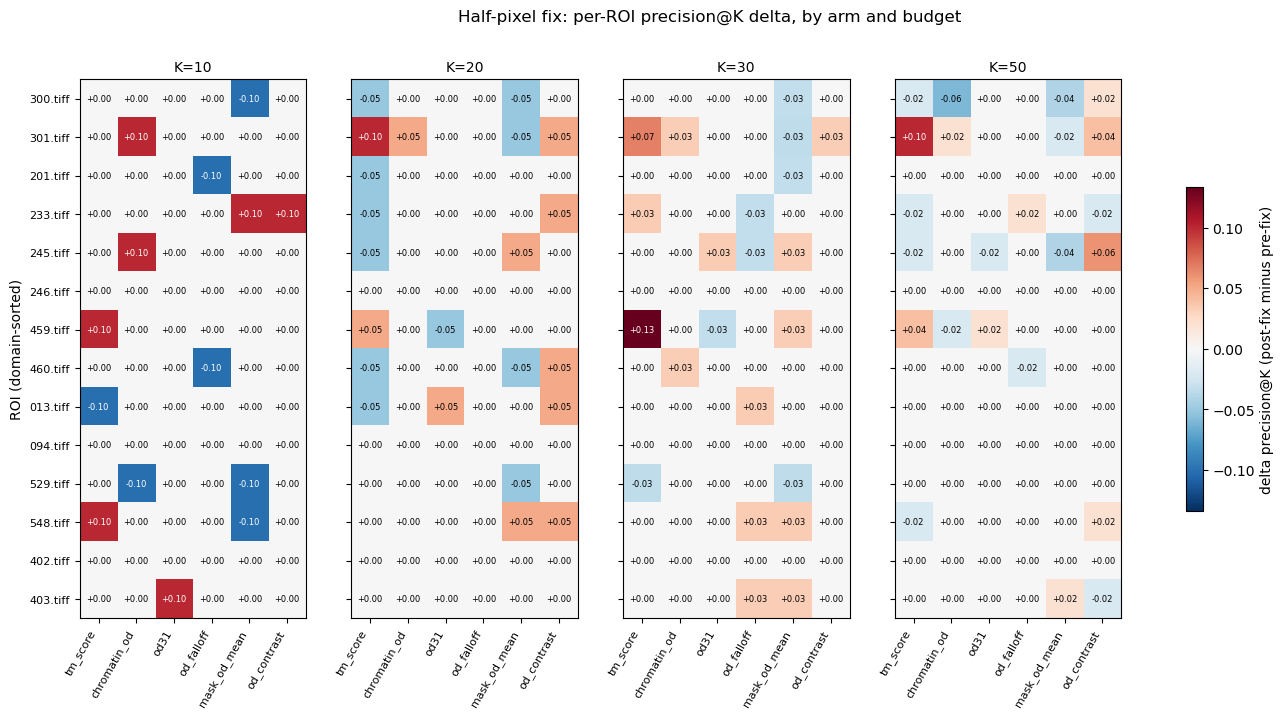

In [11]:
import matplotlib.pyplot as plt

# Figure 1: per-ROI precision_at_K delta (new minus pre-fix old), one heatmap panel per budget.
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(4.2 * len(BUDGETS), 7.0), sharey=True)
vmax_a = max(TABLE_A_DELTA[delta_cols].abs().to_numpy().max(), 1e-6)
im = None
for ax, k in zip(axes, BUDGETS):
    piv = (TABLE_A_DELTA.set_index(['file_name', 'arm'])[f'delta_precision_at_{k}']
           .unstack('arm').reindex(index=ROI_ORDER, columns=ARM_ORDER))
    im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-vmax_a, vmax=vmax_a, aspect='auto')
    ax.set_xticks(range(len(ARM_ORDER)))
    ax.set_xticklabels(ARM_ORDER, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(ROI_ORDER)))
    ax.set_yticklabels(ROI_ORDER, fontsize=8)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > vmax_a * 0.6 else 'black')
    ax.set_title(f'K={k}', fontsize=10)
axes[0].set_ylabel('ROI (domain-sorted)')
fig.colorbar(im, ax=list(axes), shrink=0.6, label='delta precision@K (post-fix minus pre-fix)')
fig.suptitle('Half-pixel fix: per-ROI precision@K delta, by arm and budget', fontsize=12)
plt.savefig('half_pix_fix_roi_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

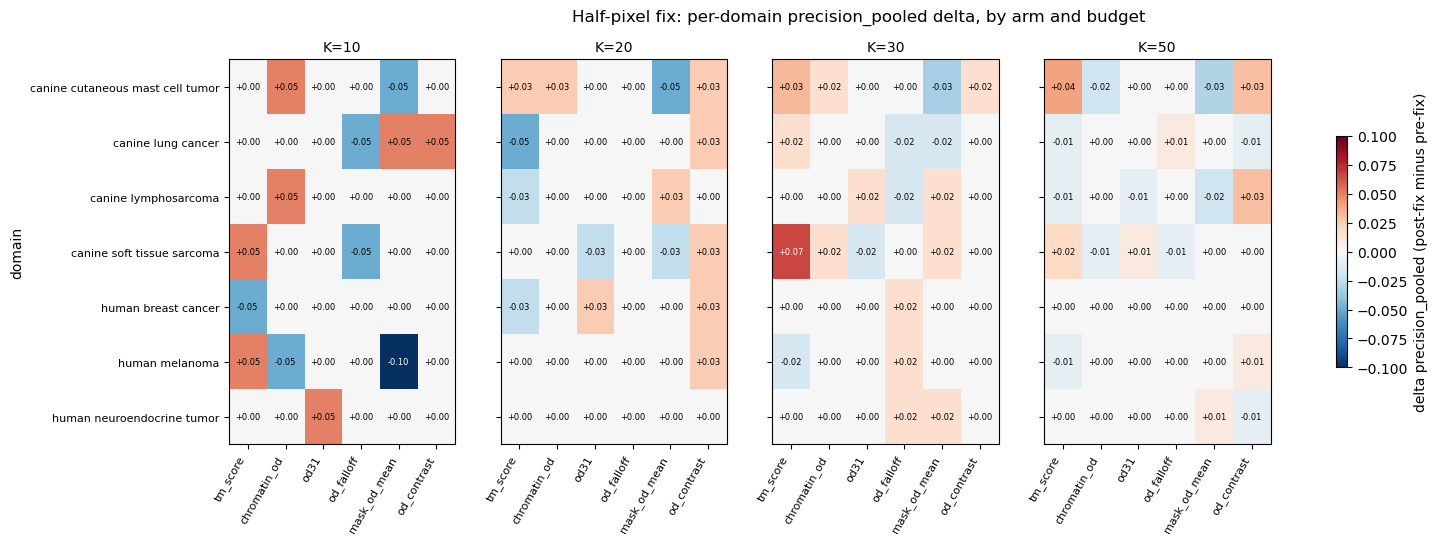

In [12]:
# Figure 2: per-domain precision_pooled delta (new minus pre-fix old), one heatmap panel per budget.
DOMAIN_ORDER = sorted(TABLE_B_DELTA['domain'].unique())

fig, axes = plt.subplots(1, len(BUDGETS), figsize=(4.2 * len(BUDGETS), 5.0), sharey=True)
vmax_b = max(TABLE_B_DELTA['delta_precision_pooled'].abs().max(), 1e-6)
im = None
for ax, k in zip(axes, BUDGETS):
    piv = (TABLE_B_DELTA[TABLE_B_DELTA['K'] == k].set_index(['domain', 'arm'])['delta_precision_pooled']
           .unstack('arm').reindex(index=DOMAIN_ORDER, columns=ARM_ORDER))
    im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-vmax_b, vmax=vmax_b, aspect='auto')
    ax.set_xticks(range(len(ARM_ORDER)))
    ax.set_xticklabels(ARM_ORDER, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(DOMAIN_ORDER)))
    ax.set_yticklabels(DOMAIN_ORDER, fontsize=8)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > vmax_b * 0.6 else 'black')
    ax.set_title(f'K={k}', fontsize=10)
axes[0].set_ylabel('domain')
fig.colorbar(im, ax=list(axes), shrink=0.6, label='delta precision_pooled (post-fix minus pre-fix)')
fig.suptitle('Half-pixel fix: per-domain precision_pooled delta, by arm and budget', fontsize=12)
plt.savefig('half_pix_fix_domain_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Domain-level: 6/28 cells tied for the max post-fix (precision_pooled granularity is coarse at 2 ROIs/domain)
ROI-level: 22/56 cells tied for the max post-fix


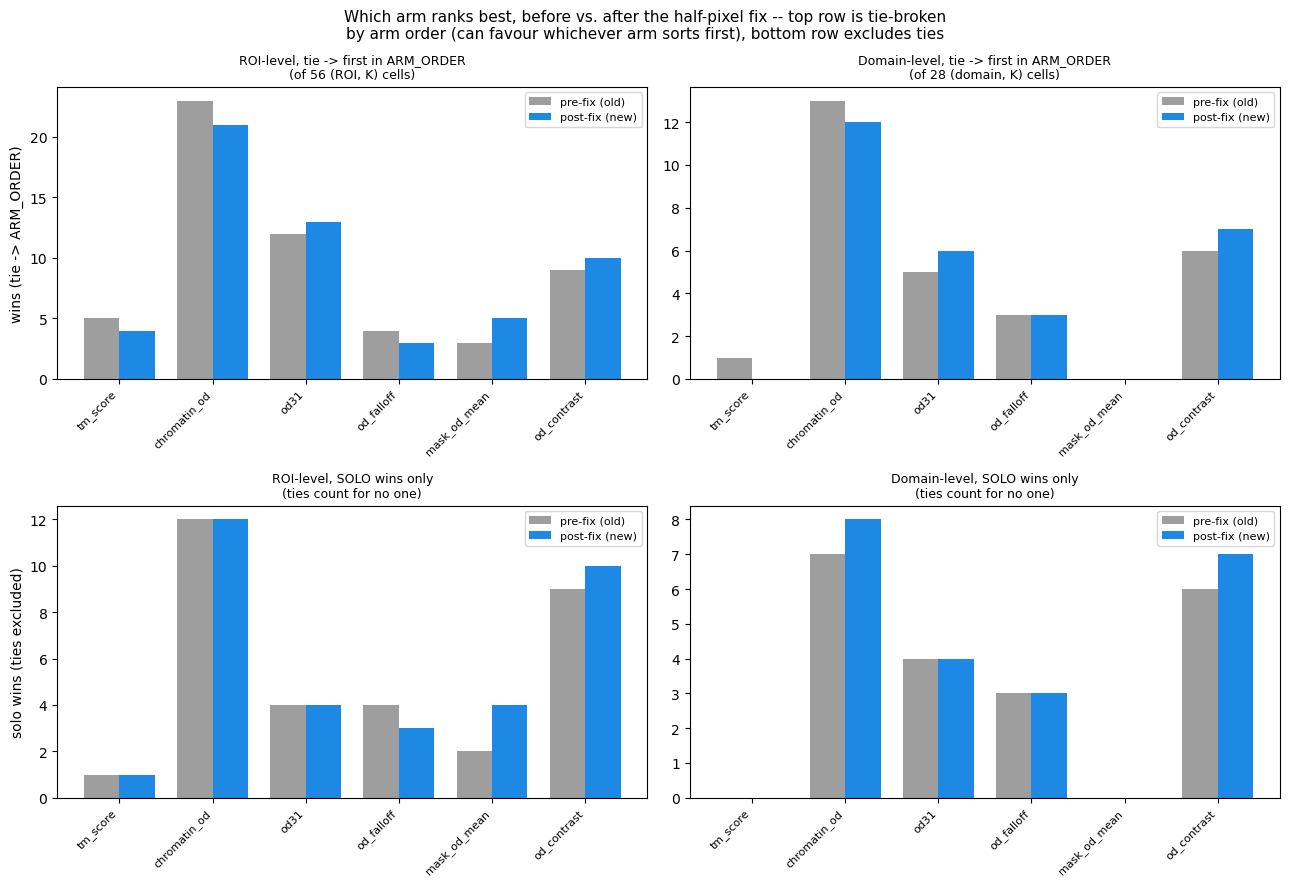


ROI-level solo win counts (post-fix):
tm_score         1
chromatin_od    12
od31             4
od_falloff       3
mask_od_mean     4
od_contrast     10

Domain-level solo win counts (post-fix):
tm_score        0
chromatin_od    8
od31            4
od_falloff      3
mask_od_mean    0
od_contrast     7


In [13]:
# Figure 3: which arm has the highest precision most often, pre- vs. post-fix, at the ROI level
# (precision_at_K) and the domain level (precision_pooled). Two counts per cell, not one:
# `total` breaks a tie to the first arm in ARM_ORDER (tm_score first) -- the same rule idxmax
# uses -- and `solo` counts only cells where that arm's max is unique, so a tie helps no one.
# precision_pooled at K=10 pools only 2 ROIs (steps of 1/20 = 0.05), so exact ties are common
# enough here that `total` alone is not a fair comparison between two arms that both land on
# the tie line often -- both counts are shown so that is not hidden.
def win_counts(df, group_cols, value_col, arm_col='arm'):
    total = {a: 0 for a in ARM_ORDER}
    solo = {a: 0 for a in ARM_ORDER}
    for _, g in df.groupby(group_cols):
        mx = g[value_col].max()
        winners = g.loc[g[value_col] == mx, arm_col].tolist()
        total[min(winners, key=ARM_ORDER.index)] += 1
        if len(winners) == 1:
            solo[winners[0]] += 1
    return pd.Series(total).reindex(ARM_ORDER), pd.Series(solo).reindex(ARM_ORDER)

roi_long_new = TABLE_A.melt(id_vars=['file_name', 'arm'], value_vars=prec_cols,
                            var_name='budget', value_name='precision')
roi_long_new['budget'] = roi_long_new['budget'].str.extract(r'(\d+)$').astype(int)
roi_long_old = OLD_A.melt(id_vars=['file_name', 'arm'], value_vars=prec_cols,
                          var_name='budget', value_name='precision')
roi_long_old['budget'] = roi_long_old['budget'].str.extract(r'(\d+)$').astype(int)

roi_wins_new, roi_solo_new = win_counts(roi_long_new, ['file_name', 'budget'], 'precision')
roi_wins_old, roi_solo_old = win_counts(roi_long_old, ['file_name', 'budget'], 'precision')
domain_wins_new, domain_solo_new = win_counts(TABLE_B, ['domain', 'K'], 'precision_pooled')
domain_wins_old, domain_solo_old = win_counts(OLD_B, ['domain', 'K'], 'precision_pooled')

n_roi_ties_new = len(ROI_ORDER) * len(BUDGETS) - int(roi_solo_new.sum())
n_domain_ties_new = len(DOMAIN_ORDER) * len(BUDGETS) - int(domain_solo_new.sum())
print(f'Domain-level: {n_domain_ties_new}/{len(DOMAIN_ORDER) * len(BUDGETS)} cells tied for the max '
      f'post-fix (precision_pooled granularity is coarse at 2 ROIs/domain)')
print(f'ROI-level: {n_roi_ties_new}/{len(ROI_ORDER) * len(BUDGETS)} cells tied for the max post-fix')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
x = np.arange(len(ARM_ORDER))
width = 0.38

panels = [
    (axes[0, 0], roi_wins_old, roi_wins_new,
     f'ROI-level, tie -> first in ARM_ORDER\n(of {len(ROI_ORDER) * len(BUDGETS)} (ROI, K) cells)'),
    (axes[0, 1], domain_wins_old, domain_wins_new,
     f'Domain-level, tie -> first in ARM_ORDER\n(of {len(DOMAIN_ORDER) * len(BUDGETS)} (domain, K) cells)'),
    (axes[1, 0], roi_solo_old, roi_solo_new, 'ROI-level, SOLO wins only\n(ties count for no one)'),
    (axes[1, 1], domain_solo_old, domain_solo_new, 'Domain-level, SOLO wins only\n(ties count for no one)'),
]
for ax, old_s, new_s, title in panels:
    ax.bar(x - width / 2, old_s.values, width, label='pre-fix (old)', color='#9e9e9e')
    ax.bar(x + width / 2, new_s.values, width, label='post-fix (new)', color='#1e88e5')
    ax.set_xticks(x)
    ax.set_xticklabels(ARM_ORDER, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel('wins (tie -> ARM_ORDER)')
axes[1, 0].set_ylabel('solo wins (ties excluded)')

fig.suptitle('Which arm ranks best, before vs. after the half-pixel fix -- top row is tie-broken\n'
            'by arm order (can favour whichever arm sorts first), bottom row excludes ties', fontsize=11)
plt.tight_layout()
plt.savefig('half_pix_fix_win_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nROI-level solo win counts (post-fix):')
print(roi_solo_new.to_string())
print('\nDomain-level solo win counts (post-fix):')
print(domain_solo_new.to_string())

In [14]:
# The best ranking metric -- direct measurement, not a composite score. Two criteria, both
# computed pre- and post-fix: mean precision_pooled across all 7 domains x 4 budgets (Table B),
# and the domain-level SOLO win count from Figure 3 (ties excluded, so this is not sensitive to
# ARM_ORDER the way the tie-broken 'total' count is). The two are reported side by side rather
# than combined into one score, and the verdict below says explicitly which one it trusts when
# they disagree.
mean_pooled_new = TABLE_B.groupby('arm')['precision_pooled'].mean().reindex(ARM_ORDER)
mean_pooled_old = OLD_B.groupby('arm')['precision_pooled'].mean().reindex(ARM_ORDER)

BEST_ARM_SUMMARY = pd.DataFrame({
    'mean_precision_pooled_old': mean_pooled_old.round(4),
    'mean_precision_pooled_new': mean_pooled_new.round(4),
    'delta_mean_precision_pooled': (mean_pooled_new - mean_pooled_old).round(4),
    'domain_solo_wins_old': domain_solo_old,
    'domain_solo_wins_new': domain_solo_new,
    'delta_domain_solo_wins': (domain_solo_new - domain_solo_old),
})
print(BEST_ARM_SUMMARY.to_string())

top_by_mean_old = mean_pooled_old.idxmax()
top_by_mean_new = mean_pooled_new.idxmax()
top_by_solo_old = domain_solo_old.idxmax()
top_by_solo_new = domain_solo_new.idxmax()
print(f'\ntop arm by mean precision_pooled: pre-fix {top_by_mean_old!r} -> post-fix {top_by_mean_new!r}')
print(f'top arm by domain-level solo wins: pre-fix {top_by_solo_old!r} -> post-fix {top_by_solo_new!r}')

gap_new = float(mean_pooled_new.max() - mean_pooled_new.sort_values(ascending=False).iloc[1])
one_hit_at_k10 = 1 / (2 * 10)  # one extra TP at K=10, pooled over 2 ROIs in a domain
verdict_changed = (top_by_solo_new != top_by_solo_old)
print(f"\nmean-precision gap between the top two arms, post-fix: {gap_new:.4f} "
      f"(one detection flipping at K=10 in a 2-ROI domain moves this by {one_hit_at_k10:.4f})")
if verdict_changed:
    print(f"Verdict: the half-pixel fix CHANGES the best-ranking-arm verdict (solo-win basis): "
          f"{top_by_solo_old!r} -> {top_by_solo_new!r}.")
else:
    print(f"Verdict: the half-pixel fix does NOT change the best-ranking-arm verdict (solo-win "
          f"basis): {top_by_solo_new!r} remains best both pre- and post-fix.")
if top_by_mean_new != top_by_solo_new:
    print(f"  (mean precision_pooled alone would instead point to {top_by_mean_new!r} -- the gap "
          f"above is the reason this notebook trusts the solo-win count over the mean here.)")

              mean_precision_pooled_old  mean_precision_pooled_new  delta_mean_precision_pooled  domain_solo_wins_old  domain_solo_wins_new  delta_domain_solo_wins
tm_score                         0.4354                     0.4391                       0.0037                     0                     0                       0
chromatin_od                     0.5673                     0.5701                       0.0028                     7                     8                       1
od31                             0.5242                     0.5260                       0.0018                     4                     4                       0
od_falloff                       0.3372                     0.3342                      -0.0030                     3                     3                       0
mask_od_mean                     0.4076                     0.4008                      -0.0068                     0                     0                       0
od_contrast     

## Closing note -- the half-pixel fix, and the best ranking metric

The original notebook's closing summary above still applies unchanged: single-seed, the axis
set and ROI set are not independent, and `od_falloff`'s weak precision@K here is a known,
not new, split from its `read_95` behaviour. This note adds only what re-running with the
corrected `tightened_template_box` changes.

- **Whether the fix matters at all.** Read the "changed cells" counts printed above Table A's
  delta computation, together with Figure 1 and Figure 2: the fix redraws the template centre
  on most of these 14 seeds (`D8_TEMPLATE_ANCHOR.md`: 12-13/14), so some movement in
  `precision_at_K` and `precision_pooled` is expected almost everywhere; the heatmaps show
  where it is largest and whether it is one-sided or mixed.
- **Whether it changes the ranking verdict.** `precision_pooled` at K=10 pools only 2 ROIs per
  domain, so exact ties between arms are common here (printed above Figure 3) -- a plain
  win-count that breaks ties by arm order is not a fair comparison between two arms that both
  land on the tie line often. Figure 3 and `BEST_ARM_SUMMARY` report both the tie-broken count
  and the tie-excluding SOLO count side by side, and the mean-`precision_pooled` gap between
  the top arms is checked against the size of a single detection flipping at K=10 before it is
  read as a ranking change. The `Verdict:` line printed just above this cell is this notebook's
  answer, treating the tie-aware (solo) win count as the trustworthy signal over the
  mean-precision comparison where the two disagree.
- **What this does not settle.** Same limit as the notebook this copies: one click per ROI, not
  D5's 5-seed sweep with a paired delta clustered at the ROI. Whatever the verdict above says is
  a single-seed observation under the corrected seed, not a decision.

## Prototype -- chromatin computed *before* NMS, used as the NMS ranking key

Everything above this point (including the pre-fix comparison and Figures 1-3) is the
original notebook, unchanged. From here on is new.

**What the six arms above cannot show.** Every arm above -- `tm_score` and all five chromatin
axes -- ranks the *same* NMS survivor pool (`pool` in `run_roi`, deduplicated by `suppress()`
using `tm_score` alone). Chromatin never influences which candidate wins a suppression cluster
or how many candidates survive NMS at all; `n_detections` is identical across all six arms
within a ROI by construction. So the six-arm table above can only ever answer "given this
pool, which sort order finds mitoses fastest" -- not "does chromatin, applied earlier, change
the pool itself."

**What this section tests.** For each ROI: re-extract the *pre-NMS* peak list at the same deep
floor (`z = -1.5`) used above, compute `chromatin_od` (`od51`, darkest-10% mean, 51 px window)
and `od_contrast` (`od51 - od_ctx`) on **every peak in that list**, not just the survivors of a
`tm_score`-first NMS -- then run NMS **itself** three times on the same peak list, at the same
7.5 um radius, varying only which score decides who wins each suppression cluster:
`tm_score` (reproduces the baseline above, byte-for-byte -- the fidelity gate below checks
this), `chromatin_od`, and `od_contrast`. Self-hit removal (`SELF_HIT_RADIUS = 5.0 px`,
referenced to `tpl_xy`) is applied identically in all three, exactly as `suppress()` does above.

This directly tests the idea in the room: computing a chromatin-similarity statistic at the TM
step, before the candidate list is ever deduplicated, rather than only re-ranking whatever
`tm_score`-NMS happened to keep.

**Why the match is re-run rather than reusing `run_roi`'s output.** `run_roi` above discards
its pre-NMS `centers`/`scores` once `pool` is built (`del ... centers, scores ...`), so they
are not available afterward. Redoing the seed draw and `matchTemplate` pass here -- rather than
editing `run_roi` to retain them -- keeps the already-verified analysis above completely
untouched; the fidelity gate below is what stands in for "this reproduces the same search",
checked explicitly rather than assumed.

**Scope.** Same 14 ROIs, same seed per ROI (`seed_index = 0`, same `[SEED_INDEX, image_id]`
stream), same channel/method/deep floor/NMS radius/self-hit radius as above. Only
`chromatin_od` and `od_contrast` are tested as NMS ranking keys, per the request that started
this section -- not all five chromatin axes from the table above. `mask_od_mean` (which needs a
gate-free Otsu pass, not just `chromatin_density`) is not recomputed here.

In [15]:
PRE_NMS_AXES = {
    'tm_score':                'score',    # baseline: reproduces the run above exactly
    'chromatin_od_pre_nms':    'od51',
    'od_contrast_pre_nms':     'od_contrast',
}
OUT_PRE_NMS_PER_ROI = '../results/precision_at_k_14roi_chromatin_pre_nms_per_roi.csv'


def run_roi_pre_nms(fn, image_id, domain, anns):
    """Re-run the search for one ROI, but NMS three times on the pre-NMS peak list --
    once by `tm_score` (must reproduce `run_roi` above exactly) and once each by
    `chromatin_od` / `od_contrast` computed on the *full* pre-NMS list.
    """
    t0 = time.time()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    del rgb
    gc.collect()

    # --- identical seed draw to run_roi above -----------------------------------------
    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        if tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed, seed_tpl, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    base_size, tpl_cx, tpl_cy = seed_tpl
    tpl_xy = (float(tpl_cx), float(tpl_cy))
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    del gray_inv
    gc.collect()

    # Gate: this redraw must land on the exact same seed run_roi already drew above --
    # checked before anything downstream is trusted, not assumed from a shared RNG stream.
    ref = ROI.loc[fn]
    seed_matches = (seed_ann_id == int(ref['seed_ann_id']) and base_size == int(ref['base_size'])
                    and np.isclose(tpl_xy[0], ref['tpl_cx']) and np.isclose(tpl_xy[1], ref['tpl_cy']))

    # --- identical match + pre-NMS extraction to run_roi above ------------------------
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding left part of the ROI unreachable (PAD={PAD})'
    del hem_p, fused_p, valid_p
    gc.collect()

    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    n_peaks = len(centers)
    assert n_peaks < MAX_PEAKS, f'{fn}: MAX_PEAKS is binding, raise it'
    del fused, valid, templates, patch
    gc.collect()

    # --- chromatin on the FULL pre-NMS peak list (the new part) ------------------------
    hem_pad = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, cv2.BORDER_REPLICATE)
    px = centers[:, 0] + OD_PAD
    py = centers[:, 1] + OD_PAD
    od51_pre = np.array([cm.chromatin_density(hem_pad, x, y, window=51) for x, y in zip(px, py)])
    od_ctx_pre = np.array([cm.chromatin_density(hem_pad, x, y, window=CTX_WINDOW, frac=CTX_FRAC)
                           for x, y in zip(px, py)])
    od_contrast_pre = od51_pre - od_ctx_pre
    n_nan_od51 = int(np.isnan(od51_pre).sum())
    n_nan_ctx = int(np.isnan(od_ctx_pre).sum())
    del hem, hem_pad
    gc.collect()

    pre_scores = {'score': scores, 'od51': od51_pre, 'od_contrast': od_contrast_pre}

    # --- NMS three times on the SAME pre-NMS peak list, varying only the ranking score -
    survivors, arms = {}, []
    for name, key in PRE_NMS_AXES.items():
        sarr = np.asarray(pre_scores[key], dtype=float)
        nan_mask = np.isnan(sarr)
        if nan_mask.any():
            sarr = sarr.copy()
            sarr[nan_mask] = -np.inf   # a peak whose chromatin is undefined never wins a cluster
        keep = nms_by_distance(centers, sarr, nms_radius)
        c, s, o, oc = centers[keep], scores[keep], od51_pre[keep], od_contrast_pre[keep]
        if len(c):
            ok = np.hypot(c[:, 0] - tpl_xy[0], c[:, 1] - tpl_xy[1]) > SELF_HIT_RADIUS
            c, s, o, oc = c[ok], s[ok], o[ok], oc[ok]
        survivors[name] = len(c)
        pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s, 'od51': o, 'od_contrast': oc})
        arms.append(cp.Arm(name, (lambda d=pool: d), rank_key=key, seeded=True, z=DEEP_FLOOR_Z,
                           z_dependent=True, nms_radius=nms_radius, caps=(MAX_PEAKS,)))

    out = cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=(H, W), mpp=mpp,
                           budgets=BUDGETS, context=dict(file_name=fn, tumor_type=domain))

    # Gate: the tm_score arm here (NMS re-run on a freshly re-extracted peak list) must
    # reproduce run_roi's own n_detections and tp_at_budget exactly -- proof this redo is
    # the same search and the same NMS, not a drifted reimplementation.
    baseline_tp = out[out['arm'] == 'tm_score'].set_index('budget')['tp_at_budget']
    ref_tp = RAW[(RAW['file_name'] == fn) & (RAW['arm'] == 'tm_score')].set_index('budget')['tp_at_budget']
    tm_score_matches = (survivors['tm_score'] == int(ref['n_detections'])
                        and baseline_tp.reindex(BUDGETS).equals(ref_tp.reindex(BUDGETS)))

    meta = dict(file_name=fn, tumor_type=domain, n_peaks_pre_nms=n_peaks,
               n_survive_tm_score=survivors['tm_score'],
               n_survive_chromatin_od=survivors['chromatin_od_pre_nms'],
               n_survive_od_contrast=survivors['od_contrast_pre_nms'],
               n_nan_od51_pre_nms=n_nan_od51, n_nan_od_ctx_pre_nms=n_nan_ctx,
               seed_reproduced=bool(seed_matches), tm_score_gate_passed=bool(tm_score_matches),
               t_total_s=round(time.time() - t0, 1))
    print(f"[{fn}] {domain:32s} n_peaks_pre_nms={n_peaks:6d}  survive: "
          f"tm_score={survivors['tm_score']:6d} chromatin_od={survivors['chromatin_od_pre_nms']:6d} "
          f"od_contrast={survivors['od_contrast_pre_nms']:6d}  gate={tm_score_matches} "
          f"[{meta['t_total_s']:.0f}s]", flush=True)
    return out, meta

In [16]:
t_run2 = time.time()
pre_nms_frames, pre_nms_meta = [], []
for fn in ROI.index:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    out, m = run_roi_pre_nms(fn, image_id, domain, annotations)
    pre_nms_frames.append(out)
    pre_nms_meta.append(m)
    gc.collect()

PRE_NMS_RAW = pd.concat(pre_nms_frames, ignore_index=True)
PRE_NMS_META = pd.DataFrame(pre_nms_meta).set_index('file_name')
print(f'\n{len(ROI)} ROIs x {len(BUDGETS)} budgets x {len(PRE_NMS_AXES)} arms = '
      f'{len(PRE_NMS_RAW)} rows in {time.time() - t_run2:.0f}s')

# --- fidelity gates: this section's redo must agree with run_roi's own committed run ------
assert PRE_NMS_META['seed_reproduced'].all(), \
    ('this section\'s seed draw diverged from run_roi\'s above on at least one ROI -- see '
     f"{PRE_NMS_META.index[~PRE_NMS_META['seed_reproduced']].tolist()}")
assert PRE_NMS_META['tm_score_gate_passed'].all(), \
    ('the tm_score-ranked NMS redo did not reproduce run_roi\'s own n_detections/tp_at_budget '
     f"exactly on {PRE_NMS_META.index[~PRE_NMS_META['tm_score_gate_passed']].tolist()} -- the "
     'pre-NMS chromatin/od_contrast numbers below cannot be trusted until this passes')
assert (PRE_NMS_META[['n_nan_od51_pre_nms', 'n_nan_od_ctx_pre_nms']] == 0).all().all(), \
    'a pre-NMS peak had undefined chromatin after the OD_PAD border pad -- see PRE_NMS_META'
assert (PRE_NMS_RAW['budget_delivered'] == PRE_NMS_RAW['budget']).all(), \
    'a budget row was starved in the pre-NMS arms -- see PRE_NMS_RAW'

print(f'\nfidelity gates: seed reproduced on {int(PRE_NMS_META["seed_reproduced"].sum())}/14, '
      f'tm_score NMS-redo exact on {int(PRE_NMS_META["tm_score_gate_passed"].sum())}/14, '
      f'0 NaN chromatin on the pre-NMS list on all 14 -- all three required, all three hold')

PRE_NMS_META[['tumor_type', 'n_peaks_pre_nms', 'n_survive_tm_score', 'n_survive_chromatin_od',
             'n_survive_od_contrast', 't_total_s']]

[013.tiff] human breast cancer              n_peaks_pre_nms= 56733  survive: tm_score= 17724 chromatin_od= 18138 od_contrast= 17861  gate=True [96s]


[094.tiff] human breast cancer              n_peaks_pre_nms= 65105  survive: tm_score= 18628 chromatin_od= 18926 od_contrast= 18835  gate=True [28s]


[201.tiff] canine lung cancer               n_peaks_pre_nms= 31314  survive: tm_score= 15848 chromatin_od= 15654 od_contrast= 15621  gate=True [14s]


[233.tiff] canine lung cancer               n_peaks_pre_nms= 46860  survive: tm_score= 17449 chromatin_od= 17659 od_contrast= 17533  gate=True [15s]


[245.tiff] canine lymphosarcoma             n_peaks_pre_nms= 58880  survive: tm_score= 17678 chromatin_od= 18087 od_contrast= 17973  gate=True [18s]


...

[460.tiff] canine soft tissue sarcoma       n_peaks_pre_nms= 24990  survive: tm_score= 15698 chromatin_od= 15671 od_contrast= 15656  gate=True [14s]


[529.tiff] human melanoma                   n_peaks_pre_nms= 35603  survive: tm_score= 16620 chromatin_od= 16665 od_contrast= 16594  gate=True [19s]


[548.tiff] human melanoma                   n_peaks_pre_nms= 47223  survive: tm_score= 17839 chromatin_od= 17872 od_contrast= 17761  gate=True [20s]



14 ROIs x 4 budgets x 3 arms = 168 rows in 325s

fidelity gates: seed reproduced on 14/14, tm_score NMS-redo exact on 14/14, 0 NaN chromatin on the pre-NMS list on all 14 -- all three required, all three hold


,tumor_type,n_peaks_pre_nms,n_survive_tm_score,n_survive_chromatin_od,n_survive_od_contrast,t_total_s
file_name,,,,,,
013.tiff,human breast cancer,56733,17724,18138,17861,96.0
094.tiff,human breast cancer,65105,18628,18926,18835,27.8
201.tiff,canine lung cancer,31314,15848,15654,15621,13.6
233.tiff,canine lung cancer,46860,17449,17659,17533,15.3
245.tiff,canine lymphosarcoma,58880,17678,18087,17973,17.7
246.tiff,canine lymphosarcoma,42028,18013,17554,17528,18.9
300.tiff,canine cutaneous mast cell tumor,33132,17940,17198,17245,13.7
301.tiff,canine cutaneous mast cell tumor,36174,17710,17359,17338,14.5
402.tiff,human neuroendocrine tumor,52211,17532,17549,17474,21.5


## Table C -- precision@K and candidate count, chromatin-first NMS vs. `tm_score`-first NMS

One row per (ROI, arm), five arms: `tm_score` (this section's own NMS-redo baseline),
`chromatin_od_pre_nms` and `od_contrast_pre_nms` (the new NMS-time fusion), plus the two
already-computed post-hoc rerank arms from Table A (`chromatin_od`, `od_contrast` -- same
candidates as `tm_score` above, just resorted, `n_detections` unchanged from the baseline).
Putting all five in one table makes the three-way comparison the request asked for readable
directly: `tm_score` alone, chromatin as a **post-hoc rerank** of the same pool, and chromatin
used **before NMS** to decide the pool itself.

In [17]:
PRE_NMS_RAW['precision_at_budget'] = PRE_NMS_RAW['tp_at_budget'] / PRE_NMS_RAW['budget_delivered']

n_detections_by_arm = {
    'tm_score': PRE_NMS_META['n_survive_tm_score'],
    'chromatin_od_pre_nms': PRE_NMS_META['n_survive_chromatin_od'],
    'od_contrast_pre_nms': PRE_NMS_META['n_survive_od_contrast'],
}
POST_HOC_ARMS = ('chromatin_od', 'od_contrast')   # already computed above, Table A

rows_c = []
for fn in order['file_name']:
    domain = ROI.loc[fn, 'tumor_type']
    row_common = dict(file_name=fn, domain=domain, n_gt_mitotic=int(ROI.loc[fn, 'n_gt_mitotic']))

    for arm in PRE_NMS_AXES:
        sub = PRE_NMS_RAW[(PRE_NMS_RAW['file_name'] == fn) & (PRE_NMS_RAW['arm'] == arm)].set_index('budget')
        r = dict(row_common, arm=arm, kind='pre-NMS ranking key',
                n_detections=int(n_detections_by_arm[arm][fn]))
        for k in BUDGETS:
            r[f'precision_at_{k}'] = round(float(sub.loc[k, 'precision_at_budget']), 4)
        rows_c.append(r)

    for arm in POST_HOC_ARMS:
        sub = TABLE_A[(TABLE_A['file_name'] == fn) & (TABLE_A['arm'] == arm)].iloc[0]
        r = dict(row_common, arm=arm, kind='post-hoc rerank (Table A)',
                n_detections=int(sub['n_detections']))
        for k in BUDGETS:
            r[f'precision_at_{k}'] = float(sub[f'precision_at_{k}'])
        rows_c.append(r)

TABLE_C = pd.DataFrame(rows_c)
TABLE_C.to_csv(OUT_PRE_NMS_PER_ROI, index=False)
print(f'-> {OUT_PRE_NMS_PER_ROI}  ({len(TABLE_C)} rows = 14 ROIs x 5 arms)')
TABLE_C

-> ../results/precision_at_k_14roi_chromatin_pre_nms_per_roi.csv  (70 rows = 14 ROIs x 5 arms)


,file_name,domain,n_gt_mitotic,arm,kind,n_detections,precision_at_10,precision_at_20,precision_at_30,precision_at_50
0,300.tiff,canine cutaneous mast cell tumor,180,tm_score,pre-NMS ranking key,17940,0.7,0.70,0.6667,0.64
1,300.tiff,canine cutaneous mast cell tumor,180,chromatin_od_pre_nms,pre-NMS ranking key,17198,1.0,0.90,0.8667,0.86
2,300.tiff,canine cutaneous mast cell tumor,180,od_contrast_pre_nms,pre-NMS ranking key,17245,0.9,0.90,0.8667,0.86
3,300.tiff,canine cutaneous mast cell tumor,180,chromatin_od,post-hoc rerank (Table A),17940,0.9,0.90,0.9000,0.86
4,300.tiff,canine cutaneous mast cell tumor,180,od_contrast,post-hoc rerank (Table A),17940,0.9,0.90,0.8667,0.88
5,301.tiff,canine cutaneous mast cell tumor,217,tm_score,pre-NMS ranking key,17710,0.9,0.90,0.8000,0.74
6,301.tiff,canine cutaneous mast cell tumor,217,chromatin_od_pre_nms,pre-NMS ranking key,17359,0.6,0.75,0.8000,0.78
7,301.tiff,canine cutaneous mast cell tumor,217,od_contrast_pre_nms,pre-NMS ranking key,17338,0.6,0.70,0.8000,0.80
8,301.tiff,canine cutaneous mast cell tumor,217,chromatin_od,post-hoc rerank (Table A),17710,0.6,0.75,0.8333,0.82
9,301.tiff,canine cutaneous mast cell tumor,217,od_contrast,post-hoc rerank (Table A),17710,0.6,0.70,0.8000,0.84


In [18]:
prec_cols_c = [f'precision_at_{k}' for k in BUDGETS]

print('=' * 96)
print('CANDIDATE COUNT AFTER NMS -- chromatin-first vs. tm_score-first (same pre-NMS peak list)')
print('=' * 96)
n_base = PRE_NMS_META['n_survive_tm_score']
for arm, col in [('chromatin_od_pre_nms', 'n_survive_chromatin_od'),
                 ('od_contrast_pre_nms', 'n_survive_od_contrast')]:
    delta = PRE_NMS_META[col] - n_base
    pct = 100 * delta / n_base
    print(f'\n{arm}:')
    print(f'  n_detections -- median {PRE_NMS_META[col].median():.0f} vs. tm_score baseline '
          f'{n_base.median():.0f}')
    print(f'  delta (arm minus tm_score) -- mean {delta.mean():+.0f}  median {delta.median():+.0f}  '
          f'range [{delta.min():+.0f}, {delta.max():+.0f}]')
    print(f'  as a percent of the baseline pool -- mean {pct.mean():+.1f}%  median {pct.median():+.1f}%')
    n_smaller = int((delta < 0).sum())
    print(f'  smaller than the tm_score-first pool on {n_smaller}/14 ROIs')

print()
print('=' * 96)
print('PRECISION@K -- three-way comparison, mean over 14 ROIs (Table C)')
print('=' * 96)
mean_by_arm = TABLE_C.groupby('arm')[prec_cols_c].mean()
arm_order_c = ['tm_score', 'chromatin_od', 'chromatin_od_pre_nms', 'od_contrast', 'od_contrast_pre_nms']
print(mean_by_arm.reindex(arm_order_c).round(4).to_string())

print()
print('-- delta vs. tm_score baseline, mean over 14 ROIs --')
delta_by_arm = (mean_by_arm.reindex(arm_order_c) - mean_by_arm.loc['tm_score']).drop('tm_score')
print(delta_by_arm.round(4).to_string())

print()
print('-- pre-NMS fusion vs. its own post-hoc rerank (does moving chromatin before NMS help '
     'beyond just reranking the tm_score pool?) --')
for pre, post in [('chromatin_od_pre_nms', 'chromatin_od'), ('od_contrast_pre_nms', 'od_contrast')]:
    d = (mean_by_arm.loc[pre] - mean_by_arm.loc[post]).round(4)
    print(f'\n{pre} minus {post}:')
    print(d.to_string())

print()
print('-- per-ROI win count: does the pre-NMS arm ever beat BOTH tm_score and its own post-hoc '
     'rerank, at the same K? --')
piv = TABLE_C.set_index(['file_name', 'arm'])[prec_cols_c]
for pre, post in [('chromatin_od_pre_nms', 'chromatin_od'), ('od_contrast_pre_nms', 'od_contrast')]:
    wins = 0
    for fn in ROI.index:
        p_pre = piv.loc[(fn, pre)]
        p_post = piv.loc[(fn, post)]
        p_base = piv.loc[(fn, 'tm_score')]
        wins += int(((p_pre > p_post) & (p_pre > p_base)).sum())
    print(f'{pre}: strictly beats both tm_score AND {post} on {wins}/{14 * len(BUDGETS)} '
         f'(ROI, K) cells')

CANDIDATE COUNT AFTER NMS -- chromatin-first vs. tm_score-first (same pre-NMS peak list)

chromatin_od_pre_nms:
  n_detections -- median 17552 vs. tm_score baseline 17694
  delta (arm minus tm_score) -- mean -38  median +17  range [-742, +414]
  as a percent of the baseline pool -- mean -0.2%  median +0.1%
  smaller than the tm_score-first pool on 6/14 ROIs

od_contrast_pre_nms:
  n_detections -- median 17501 vs. tm_score baseline 17694
  delta (arm minus tm_score) -- mean -115  median -68  range [-695, +295]
  as a percent of the baseline pool -- mean -0.7%  median -0.4%
  smaller than the tm_score-first pool on 10/14 ROIs

PRECISION@K -- three-way comparison, mean over 14 ROIs (Table C)
                      precision_at_10  precision_at_20  precision_at_30  precision_at_50
arm                                                                                     
tm_score                       0.5000           0.4536           0.4286           0.3743
chromatin_od                   0.62